In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [6]:
df = pd.read_csv('data/pre-thin-data.csv')
df.head()

,Row,Tree,pre_DBH,pre_HT,pre_LLC,pre_stem_vol
0,1,1,10.8,69.788672,NaN,19.593049
1,1,2,6.8,62.771152,NaN,7.127531
2,1,3,6.1,60.770923,NaN,5.601351
3,1,4,5.5,58.873375,NaN,4.458079
4,1,5,10.5,69.522875,NaN,18.461945


In [7]:
df['status'] = df['pre_HT'].apply(lambda x: 'Alive' if pd.notnull(x) and x > 0 else 'Dead')

status_counts = df['status'].value_counts()
status_percent = df['status'].value_counts(normalize=True) * 100

## Spatial map - quartiles

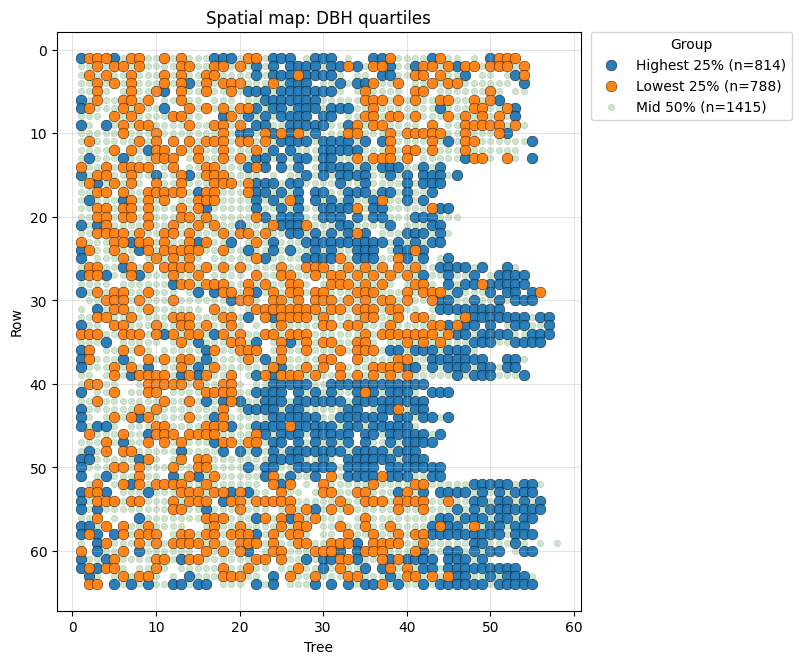

In [8]:
def percentile_flags(df,metric='pre_DBH',alive=True):
    d=df.copy()
    if alive and 'status' in d.columns:
        d=d[d['status']=='Alive']
    vals=d[metric].dropna()
    q1,q3=vals.quantile(0.25),vals.quantile(0.75)
    d['quartile']='Mid 50%'
    d.loc[d[metric]<=q1,'quartile']='Lowest 25%'
    d.loc[d[metric]>=q3,'quartile']='Highest 25%'
    return d,q1,q3

def percentile_map_plot(df,metric='pre_DBH',row_col=('Row','Tree'),alive=True,title=None):
    d,q1,q3=percentile_flags(df,metric,alive=alive)
    r,c=row_col

    order=['Lowest 25%','Mid 50%','Highest 25%']
    counts=(d['quartile'].value_counts()
              .reindex(order)
              .fillna(0).astype(int)
              .to_dict())

    fig,ax=plt.subplots(figsize=(8,8))
    style={'Lowest 25%':dict(s=60,alpha=0.95),
           'Mid 50%':    dict(s=20,alpha=0.25),
           'Highest 25%':dict(s=60,alpha=0.95)}

    for lab,g in d.groupby('quartile'):
        lbl=f"{lab} (n={counts.get(lab,0)})"
        kw=style.get(lab,dict(s=40,alpha=0.6))
        ax.scatter(g[c],g[r],edgecolors='k',linewidths=0.3,label=lbl,**kw)

    ax.set_xlabel(c); ax.set_ylabel(r)
    ax.set_title(title or f'{metric}: Lowest vs Highest Quartiles (Q1={q1:.2f}, Q3={q3:.2f})')
    ax.set_aspect('equal',adjustable='box'); ax.invert_yaxis(); ax.grid(True,linewidth=0.5,alpha=0.5)

    ax.legend(title='Group',loc='upper left',bbox_to_anchor=(1.02,1),borderaxespad=0.)
    fig.subplots_adjust(right=0.78)  # reserve space on the right for legend
    plt.show()


percentile_map_plot(df,metric='pre_DBH',title='Spatial map: DBH quartiles')

## Three row thinning

### Row Selection with Spatial Map

=== Stand Analysis (3-row) ===
% trees removed: 32.52
% volume removed: 32.54
Trees kept: 2036
Trees removed: 981
Q1 pre (count): 788
Q1 post (count): 534
Q1 retention ratio (post/pre): 0.678
Q4 pre (count): 814
Q4 post (count): 562
Q4 retention ratio (post/pre): 0.69
Removal purity: Q1 share of removed: 0.259
Keep purity: Q4 share of kept: 0.276
Post-thinning total volume: 27757.68
Volume removed: 13388.63
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.98
Change in median DBH: 0.0
Change in mean DBH: -0.0


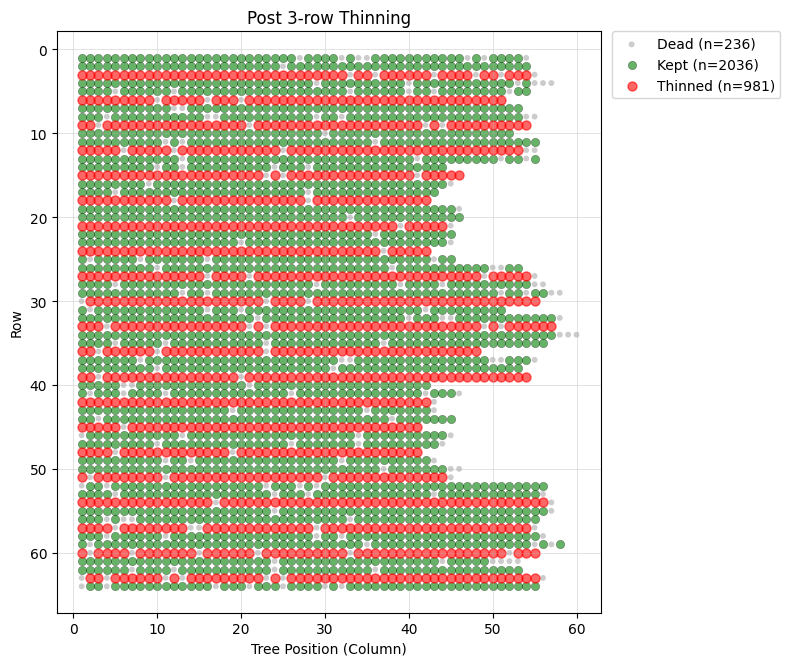

In [9]:

def three_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3)
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d['status'].eq('Alive')
    rows_to_thin = ((d['Row'] - start_row) % 3 == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis_3row(d_thin, bold=False):
    alive = d_thin[d_thin['status'] == 'Alive'].copy()
    kept  = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol    = float(kept['pre_stem_vol'].sum())  if len(kept)  else 0.0
    removed_total_vol = float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh  = float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh    = float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh = float(kept['pre_DBH'].median())  if len(kept)  else np.nan
    post_mean_dbh   = float(kept['pre_DBH'].mean())    if len(kept)  else np.nan

    q1 = alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3 = alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre  = (alive['pre_DBH'] <= q1).sum() if len(alive) else 0  # Q1
    H_pre  = (alive['pre_DBH'] >= q3).sum() if len(alive) else 0  # Q4
    L_post = (kept ['pre_DBH'] <= q1).sum() if len(kept)  else 0
    H_post = (kept ['pre_DBH'] >= q3).sum() if len(kept)  else 0

    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan

    total_removed = len(removed)
    total_kept    = len(kept)
    q1_removed = L_pre - L_post
    removal_purity_q1 = (q1_removed / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)        if total_kept    > 0 else np.nan

    change_median = (post_median_dbh - pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean   = (post_mean_dbh   - pre_mean_dbh)   if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    res = {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),
        'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),
        'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median_dbh, 2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2)   if not np.isnan(pre_mean_dbh)   else np.nan,
        'Post-thinning median DBH': round(post_median_dbh, 2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh, 2)     if not np.isnan(post_mean_dbh)   else np.nan,
        'Change in median DBH': round(change_median, 2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH':   round(change_mean, 2)   if not np.isnan(change_mean)   else np.nan
    }

    if bold:
        BOLD, RESET = "\033[1m", "\033[0m"
        for key in ('% volume removed',
                    'Q1 retention ratio (post/pre)',
                    'Q4 retention ratio (post/pre)',
                    'Change in median DBH',
                    'Change in mean DBH'):
            if key in res and not (isinstance(res[key], float) and np.isnan(res[key])):
                res[key] = f"{BOLD}{res[key]}{RESET}"

    return res

def plot_3row(d_thin, title='3-row thinning – quartile retention'):
    rep = stand_analysis_3row(d_thin, bold=False)  # keep values numeric

    plt.figure(figsize=(6, 4))
    labels = ['Q1 retention %', 'Q4 retention %']
    q1_val = rep['Q1 retention ratio (post/pre)']
    q4_val = rep['Q4 retention ratio (post/pre)']
    vals = [
        100 * q1_val if rep['Q1 pre (count)'] > 0 and not np.isnan(q1_val) else np.nan,
        100 * q4_val if rep['Q4 pre (count)'] > 0 and not np.isnan(q4_val) else np.nan
    ]
    bars = plt.bar(labels, vals)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            plt.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.ylim(0, 100)
    plt.ylabel('Percent')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    cats = ['Q1', 'Q4']
    pre  = [rep['Q1 pre (count)'], rep['Q4 pre (count)']]
    post = [rep['Q1 post (count)'], rep['Q4 post (count)']]
    x = np.arange(len(cats)); w = 0.35
    plt.bar(x - w/2, pre,  width=w, label='Pre')
    plt.bar(x + w/2, post, width=w, label='Post')
    for xi, p1, p2 in zip(x, pre, post):
        plt.text(xi - w/2, p1 + 0.5, str(p1), ha='center')
        plt.text(xi + w/2, p2 + 0.5, str(p2), ha='center')
    plt.xticks(x, cats)
    plt.ylabel('Count')
    plt.title('Quartile counts (pre vs post)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return rep

def spatial_map_3row(df_thinned, title):
    alive = df_thinned[df_thinned['status'] == 'Alive']
    kept = alive[alive['thin_decision'] == 'Keep']
    thinned = alive[alive['thin_decision'] == 'Thin']
    dead = df_thinned[df_thinned['status'] == 'Dead']

    fig, ax = plt.subplots(figsize=(8, 8))

    if not dead.empty:
        ax.scatter(dead['Tree'], dead['Row'], s=18, c='gray', alpha=0.4,
                   label=f'Dead (n={len(dead)})', edgecolors='none')

    if not kept.empty:
        ax.scatter(kept['Tree'], kept['Row'], s=36, c='green', alpha=0.6,
                   label=f'Kept (n={len(kept)})', edgecolors='k', linewidths=0.3, marker='o')

    if not thinned.empty:
        ax.scatter(thinned['Tree'], thinned['Row'], s=42, c='red', alpha=0.6,
                   label=f'Thinned (n={len(thinned)})', marker='o', linewidths=1.0)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Tree Position (Column)')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.5)

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()



three_row_thinned = three_row_thinning(df, start_row=3)
report_3row = stand_analysis_3row(three_row_thinned, bold=True)
print("=== Stand Analysis (3-row) ===")
for k, v in report_3row.items():
    print(f"{k}: {v}")
# plot_3row(three_row_thinned)
spatial_map_3row(three_row_thinned, title='Post 3-row Thinning')


### Consolidated Table

In [10]:
def three_row_thinning(df,start_row=1):
    assert start_row in (1,2,3)
    d=df.copy()
    d['thin_decision']='Dead (ignored)'
    alive=d['status'].eq('Alive')
    rows_to_thin=((d['Row']-start_row)%3==0)
    d.loc[alive & rows_to_thin,'thin_decision']='Thin'
    d.loc[alive & ~rows_to_thin,'thin_decision']='Keep'
    return d

def stand_analysis_3row(d_thin):
    alive=d_thin[d_thin['status']=='Alive'].copy()
    kept =alive[alive['thin_decision']=='Keep']
    removed=alive[alive['thin_decision']=='Thin']

    pre_total_vol=float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol=float(kept['pre_stem_vol'].sum()) if len(kept) else 0.0
    removed_total_vol=float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh=float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh  =float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh=float(kept['pre_DBH'].median()) if len(kept)  else np.nan
    post_mean_dbh  =float(kept['pre_DBH'].mean())   if len(kept)  else np.nan
    change_median=(post_median_dbh-pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean  =(post_mean_dbh-pre_mean_dbh)     if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    q1=alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3=alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre =(alive['pre_DBH']<=q1).sum() if len(alive) else 0
    H_pre =(alive['pre_DBH']>=q3).sum() if len(alive) else 0
    L_post=(kept ['pre_DBH']<=q1).sum() if len(kept)  else 0
    H_post=(kept ['pre_DBH']>=q3).sum() if len(kept)  else 0

    r_q1=(L_post/L_pre) if L_pre>0 else np.nan
    r_q4=(H_post/H_pre) if H_pre>0 else np.nan

    total_removed=len(removed); total_kept=len(kept)
    q1_removed=L_pre-L_post
    removal_purity_q1=(q1_removed/total_removed) if total_removed>0 else np.nan
    keep_purity_q4=(H_post/total_kept) if total_kept>0 else np.nan

    return {
        '% trees removed': round((len(removed)/len(alive))*100,2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol/pre_total_vol)*100,2) if pre_total_vol>0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),  'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1,3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),  'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4,3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1,3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4,3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol,2),
        'Volume removed': round(removed_total_vol,2),
        'Pre-thinning median DBH': round(pre_median_dbh,2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh,2) if not np.isnan(pre_mean_dbh) else np.nan,
        'Post-thinning median DBH': round(post_median_dbh,2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh,2) if not np.isnan(post_mean_dbh) else np.nan,
        'Change in median DBH': round(change_median,2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH': round(change_mean,2) if not np.isnan(change_mean) else np.nan,
    }


def compare_analyses_3row(rows:list, title):
    want = [
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 pre (count)','Q1 post (count)','Q1 retention ratio (post/pre)',
        'Q4 pre (count)','Q4 post (count)','Q4 retention ratio (post/pre)',
        'Removal purity: Q1 share of removed','Keep purity: Q4 share of kept',
        'Post-thinning total volume','Volume removed',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH'
    ]
    comp = pd.DataFrame(rows).set_index('Strategy')
    comp = comp[ [c for c in want if c in comp.columns] ]

    count_cols = ['Trees kept','Trees removed','Q1 pre (count)','Q1 post (count)','Q4 pre (count)','Q4 post (count)']
    ratio_cols  = ['Q1 retention ratio (post/pre)','Q4 retention ratio (post/pre)','Removal purity: Q1 share of removed','Keep purity: Q4 share of kept']
    two_cols = [c for c in comp.columns if c not in count_cols + ratio_cols]

    fmt = {c: '{:,.0f}' for c in count_cols if c in comp}
    fmt.update({c: '{:.3f}' for c in ratio_cols if c in comp})
    fmt.update({c: '{:,.2f}' for c in two_cols})

    sty = (comp.style
           .format(fmt)
           .set_caption(title)
           .set_properties(**{'font-variant-numeric':'tabular-nums'}))
    return sty

rows_3=[]
for s in (1,2,3):
    d3 = three_row_thinning(df, start_row=s)
    a3 = stand_analysis_3row(d3)
    a3['Strategy'] = f'3-row start={s}'
    rows_3.append(a3)

comp3 = pd.DataFrame(rows_3)
if {'Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'} <= set(comp3.columns):
    rows_3 = (comp3
              .sort_values(by=['Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'],
                           ascending=[False, True])
              .to_dict('records'))

display(compare_analyses_3row(rows_3, title='3-row Thinning – Comparison'))


,% trees removed,% volume removed,Trees kept,Trees removed,Q1 pre (count),Q1 post (count),Q1 retention ratio (post/pre),Q4 pre (count),Q4 post (count),Q4 retention ratio (post/pre),Removal purity: Q1 share of removed,Keep purity: Q4 share of kept,Post-thinning total volume,Volume removed,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH
Strategy,,,,,,,,,,,,,,,,,,,,
3-row start=3,32.52,32.54,"2,036",981,788,534,0.678,814,562,0.690,0.259,0.276,"27,757.68","13,388.63",8.90,8.98,8.90,8.98,0.00,-0.00
3-row start=2,33.08,33.06,"2,019",998,788,523,0.664,814,539,0.662,0.266,0.267,"27,544.55","13,601.76",8.90,8.98,8.90,8.98,0.00,0.00
3-row start=1,34.41,34.40,"1,979","1,038",788,519,0.659,814,527,0.647,0.259,0.266,"26,990.38","14,155.92",8.90,8.98,8.90,8.98,0.00,-0.00


## Four row thinning

### Row Selection with Spatial Map

=== Stand Analysis (4-row) ===
% trees removed: 25.32
% volume removed: 25.14
Trees kept: 2253
Trees removed: 764
Q1 pre (count): 788
Q1 post (count): 597
Q1 retention ratio (post/pre): 0.758
Q4 pre (count): 814
Q4 post (count): 621
Q4 retention ratio (post/pre): 0.763
Removal purity: Q1 share of removed: 0.25
Keep purity: Q4 share of kept: 0.276
Post-thinning total volume: 30804.13
Volume removed: 10342.17
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.98
Change in median DBH: 0.0
Change in mean DBH: -0.0


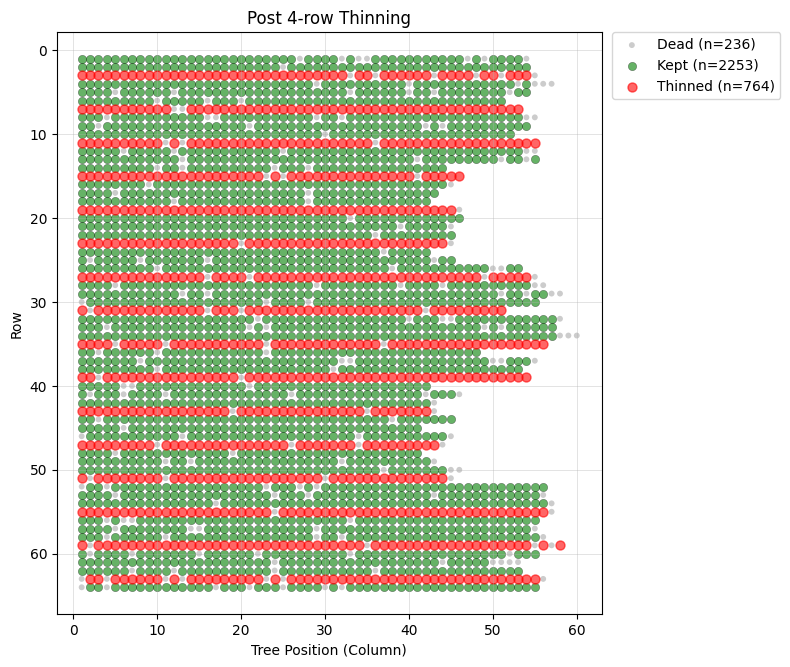

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def four_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3, 4)
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d['status'].eq('Alive')
    rows_to_thin = ((d['Row'] - start_row) % 4 == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis_4row(d_thin, bold=False):
    alive = d_thin[d_thin['status'] == 'Alive'].copy()
    kept  = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol    = float(kept['pre_stem_vol'].sum())  if len(kept)  else 0.0
    removed_total_vol = float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh  = float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh    = float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh = float(kept['pre_DBH'].median())  if len(kept)  else np.nan
    post_mean_dbh   = float(kept['pre_DBH'].mean())    if len(kept)  else np.nan

    q1 = alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3 = alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre  = (alive['pre_DBH'] <= q1).sum() if len(alive) else 0  # Q1
    H_pre  = (alive['pre_DBH'] >= q3).sum() if len(alive) else 0  # Q4
    L_post = (kept ['pre_DBH'] <= q1).sum() if len(kept)  else 0
    H_post = (kept ['pre_DBH'] >= q3).sum() if len(kept)  else 0

    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan

    total_removed = len(removed)
    total_kept    = len(kept)
    q1_removed = L_pre - L_post
    removal_purity_q1 = (q1_removed / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)        if total_kept    > 0 else np.nan

    change_median = (post_median_dbh - pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean   = (post_mean_dbh   - pre_mean_dbh)   if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    res = {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),
        'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),
        'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median_dbh, 2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2)   if not np.isnan(pre_mean_dbh)   else np.nan,
        'Post-thinning median DBH': round(post_median_dbh, 2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh, 2)     if not np.isnan(post_mean_dbh)   else np.nan,
        'Change in median DBH': round(change_median, 2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH':   round(change_mean, 2)   if not np.isnan(change_mean)   else np.nan
    }

    if bold:
        BOLD, RESET = "\033[1m", "\033[0m"
        for key in ('% volume removed',
                    'Q1 retention ratio (post/pre)',
                    'Q4 retention ratio (post/pre)',
                    'Change in median DBH',
                    'Change in mean DBH'):
            if key in res and not (isinstance(res[key], float) and np.isnan(res[key])):
                res[key] = f"{BOLD}{res[key]}{RESET}"

    return res

def plot_4row(d_thin, title='4-row thinning – quartile retention'):
    rep = stand_analysis_4row(d_thin, bold=False)  # keep values numeric

    plt.figure(figsize=(6, 4))
    labels = ['Q1 retention %', 'Q4 retention %']
    q1_val = rep['Q1 retention ratio (post/pre)']
    q4_val = rep['Q4 retention ratio (post/pre)']
    vals = [
        100 * q1_val if rep['Q1 pre (count)'] > 0 and not np.isnan(q1_val) else np.nan,
        100 * q4_val if rep['Q4 pre (count)'] > 0 and not np.isnan(q4_val) else np.nan
    ]
    bars = plt.bar(labels, vals)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            plt.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.ylim(0, 100)
    plt.ylabel('Percent')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    cats = ['Q1', 'Q4']
    pre  = [rep['Q1 pre (count)'], rep['Q4 pre (count)']]
    post = [rep['Q1 post (count)'], rep['Q4 post (count)']]
    x = np.arange(len(cats)); w = 0.35
    plt.bar(x - w/2, pre,  width=w, label='Pre')
    plt.bar(x + w/2, post, width=w, label='Post')
    for xi, p1, p2 in zip(x, pre, post):
        plt.text(xi - w/2, p1 + 0.5, str(p1), ha='center')
        plt.text(xi + w/2, p2 + 0.5, str(p2), ha='center')
    plt.xticks(x, cats)
    plt.ylabel('Count')
    plt.title('Quartile counts (pre vs post)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return rep

def spatial_map_4row(df_thinned, title='Post Thinning'):
    alive = df_thinned[df_thinned['status'] == 'Alive']
    kept = alive[alive['thin_decision'] == 'Keep']
    thinned = alive[alive['thin_decision'] == 'Thin']
    dead = df_thinned[df_thinned['status'] == 'Dead']

    fig, ax = plt.subplots(figsize=(8, 8))

    if not dead.empty:
        ax.scatter(dead['Tree'], dead['Row'], s=18, c='gray', alpha=0.4,
                   label=f'Dead (n={len(dead)})', edgecolors='none')

    if not kept.empty:
        ax.scatter(kept['Tree'], kept['Row'], s=36, c='green', alpha=0.6,
                   label=f'Kept (n={len(kept)})', edgecolors='k', linewidths=0.3, marker='o')

    if not thinned.empty:
        ax.scatter(thinned['Tree'], thinned['Row'], s=42, c='red', alpha=0.6,
                   label=f'Thinned (n={len(thinned)})', marker='o', linewidths=1.0)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Tree Position (Column)')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.5)

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()
    
four_row_thinned = four_row_thinning(df, start_row=3)

report_4row = stand_analysis_4row(four_row_thinned, bold=True)
print("=== Stand Analysis (4-row) ===")
for k, v in report_4row.items():
    print(f"{k}: {v}")

# plot_4row(four_row_thinned)
spatial_map_4row(four_row_thinned, title='Post 4-row Thinning')

### Consolidated Table

In [109]:
import numpy as np
import pandas as pd

def four_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3, 4)
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d['status'].eq('Alive')
    rows_to_thin = ((d['Row'] - start_row) % 4 == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis_4row(d_thin):
    alive = d_thin[d_thin['status'] == 'Alive'].copy()
    kept  = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol    = float(kept['pre_stem_vol'].sum())  if len(kept)  else 0.0
    removed_total_vol = float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh  = float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh    = float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh = float(kept['pre_DBH'].median())  if len(kept)  else np.nan
    post_mean_dbh   = float(kept['pre_DBH'].mean())    if len(kept)  else np.nan
    change_median = (post_median_dbh - pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean   = (post_mean_dbh   - pre_mean_dbh)   if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    q1 = alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3 = alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre  = (alive['pre_DBH'] <= q1).sum() if len(alive) else 0
    H_pre  = (alive['pre_DBH'] >= q3).sum() if len(alive) else 0
    L_post = (kept ['pre_DBH'] <= q1).sum() if len(kept)  else 0
    H_post = (kept ['pre_DBH'] >= q3).sum() if len(kept)  else 0

    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan

    total_removed = len(removed); total_kept = len(kept)
    q1_removed = L_pre - L_post
    removal_purity_q1 = (q1_removed / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)        if total_kept    > 0 else np.nan

    return {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),  'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),  'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median_dbh, 2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2)   if not np.isnan(pre_mean_dbh)   else np.nan,
        'Post-thinning median DBH': round(post_median_dbh, 2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh, 2)     if not np.isnan(post_mean_dbh)   else np.nan,
        'Change in median DBH': round(change_median, 2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH':   round(change_mean, 2)   if not np.isnan(change_mean)   else np.nan,
    }

def compare_analyses_4row(rows:list, title):
    want = [
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 pre (count)','Q1 post (count)','Q1 retention ratio (post/pre)',
        'Q4 pre (count)','Q4 post (count)','Q4 retention ratio (post/pre)',
        'Removal purity: Q1 share of removed','Keep purity: Q4 share of kept',
        'Post-thinning total volume','Volume removed',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH'
    ]
    comp = pd.DataFrame(rows).set_index('Strategy')
    comp = comp[[c for c in want if c in comp.columns]]

    count_cols = ['Trees kept','Trees removed','Q1 pre (count)','Q1 post (count)','Q4 pre (count)','Q4 post (count)']
    ratio_cols = ['Q1 retention ratio (post/pre)','Q4 retention ratio (post/pre)','Removal purity: Q1 share of removed','Keep purity: Q4 share of kept']
    two_cols   = [c for c in comp.columns if c not in count_cols + ratio_cols]

    fmt = {c: '{:,.0f}' for c in count_cols if c in comp}
    fmt.update({c: '{:.3f}' for c in ratio_cols if c in comp})
    fmt.update({c: '{:,.2f}' for c in two_cols})

    return (comp.style
            .format(fmt)
            .set_caption(title)
            .set_properties(**{'font-variant-numeric':'tabular-nums'}))

rows_4 = []
for s in (1,2,3,4):
    d4 = four_row_thinning(df, start_row=s)
    a4 = stand_analysis_4row(d4)
    a4['Strategy'] = f'4-row start={s}'
    rows_4.append(a4)

comp4 = pd.DataFrame(rows_4)
if {'Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'} <= set(comp4.columns):
    rows_4 = (comp4
              .sort_values(by=['Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'],
                           ascending=[False, True])
              .to_dict('records'))

from IPython.display import display
display(compare_analyses_4row(rows_4, title='4-row Thinning – Comparison'))


,% trees removed,% volume removed,Trees kept,Trees removed,Q1 pre (count),Q1 post (count),Q1 retention ratio (post/pre),Q4 pre (count),Q4 post (count),Q4 retention ratio (post/pre),Removal purity: Q1 share of removed,Keep purity: Q4 share of kept,Post-thinning total volume,Volume removed,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH
Strategy,,,,,,,,,,,,,,,,,,,,
4-row start=3,25.32,25.14,"2,253",764,788,597,0.758,814,621,0.763,0.250,0.276,"30,804.13","10,342.17",8.90,8.98,8.90,8.98,0.00,-0.00
4-row start=2,25.39,24.95,"2,251",766,788,554,0.703,814,613,0.753,0.305,0.272,"30,880.13","10,266.18",8.90,8.98,8.90,9.01,0.00,0.03
4-row start=1,24.56,24.64,"2,276",741,788,603,0.765,814,606,0.744,0.250,0.266,"31,006.54","10,139.76",8.90,8.98,8.90,8.97,0.00,-0.01
4-row start=4,24.73,25.27,"2,271",746,788,610,0.774,814,602,0.740,0.239,0.265,"30,748.11","10,398.19",8.90,8.98,8.90,8.95,0.00,-0.03


## Five row thinning

### Row Selection with Spatial Map

=== Stand Analysis (5-row) ===
% trees removed: 20.35
% volume removed: 20.39
Trees kept: 2403
Trees removed: 614
Q1 pre (count): 788
Q1 post (count): 631
Q1 retention ratio (post/pre): 0.801
Q4 pre (count): 814
Q4 post (count): 646
Q4 retention ratio (post/pre): 0.794
Removal purity: Q1 share of removed: 0.256
Keep purity: Q4 share of kept: 0.269
Post-thinning total volume: 32758.12
Volume removed: 8388.19
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.98
Change in median DBH: 0.0
Change in mean DBH: -0.0


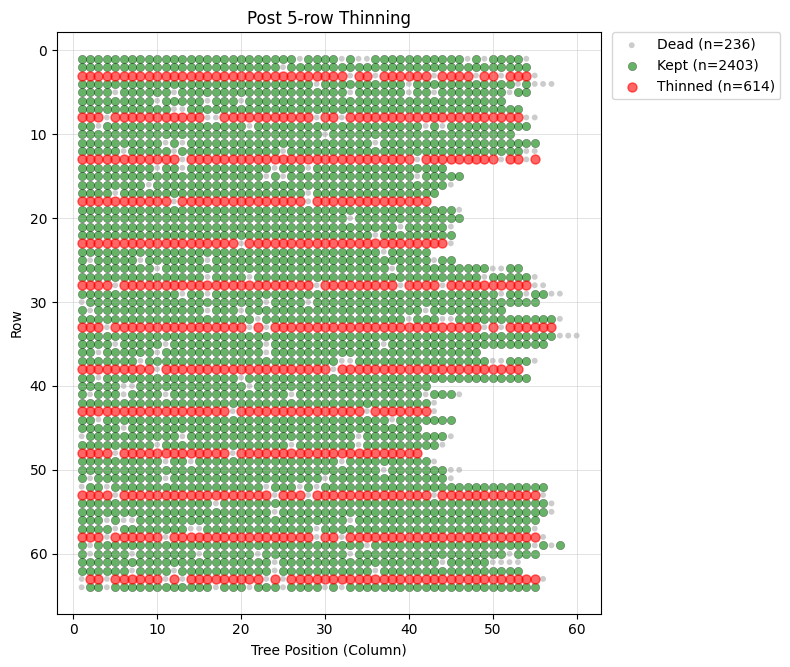

In [110]:
def five_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3, 4, 5)
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d['status'].eq('Alive')
    rows_to_thin = ((d['Row'] - start_row) % 5 == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis_5row(d_thin, bold=False):
    alive = d_thin[d_thin['status'] == 'Alive'].copy()
    kept  = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol    = float(kept['pre_stem_vol'].sum())  if len(kept)  else 0.0
    removed_total_vol = float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh  = float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh    = float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh = float(kept['pre_DBH'].median())  if len(kept)  else np.nan
    post_mean_dbh   = float(kept['pre_DBH'].mean())    if len(kept)  else np.nan

    q1 = alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3 = alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre  = (alive['pre_DBH'] <= q1).sum() if len(alive) else 0
    H_pre  = (alive['pre_DBH'] >= q3).sum() if len(alive) else 0
    L_post = (kept ['pre_DBH'] <= q1).sum() if len(kept)  else 0
    H_post = (kept ['pre_DBH'] >= q3).sum() if len(kept)  else 0

    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan

    total_removed = len(removed)
    total_kept    = len(kept)
    q1_removed = L_pre - L_post
    removal_purity_q1 = (q1_removed / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)        if total_kept    > 0 else np.nan

    change_median = (post_median_dbh - pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean   = (post_mean_dbh   - pre_mean_dbh)   if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    res = {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),
        'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),
        'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median_dbh, 2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2)   if not np.isnan(pre_mean_dbh)   else np.nan,
        'Post-thinning median DBH': round(post_median_dbh, 2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh, 2)     if not np.isnan(post_mean_dbh)   else np.nan,
        'Change in median DBH': round(change_median, 2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH':   round(change_mean, 2)   if not np.isnan(change_mean)   else np.nan
    }

    if bold:
        BOLD, RESET = "\033[1m", "\033[0m"
        for key in ('% volume removed',
                    'Q1 retention ratio (post/pre)',
                    'Q4 retention ratio (post/pre)',
                    'Change in median DBH',
                    'Change in mean DBH'):
            if key in res and not (isinstance(res[key], float) and np.isnan(res[key])):
                res[key] = f"{BOLD}{res[key]}{RESET}"

    return res

def plot_5row(d_thin, title='5-row thinning – quartile retention'):
    rep = stand_analysis_5row(d_thin, bold=False)

    plt.figure(figsize=(6, 4))
    labels = ['Q1 retention %', 'Q4 retention %']
    q1_val = rep['Q1 retention ratio (post/pre)']
    q4_val = rep['Q4 retention ratio (post/pre)']
    vals = [
        100 * q1_val if rep['Q1 pre (count)'] > 0 and not np.isnan(q1_val) else np.nan,
        100 * q4_val if rep['Q4 pre (count)'] > 0 and not np.isnan(q4_val) else np.nan
    ]
    bars = plt.bar(labels, vals)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            plt.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.ylim(0, 100); plt.ylabel('Percent'); plt.title(title)
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8, 4))
    cats = ['Q1', 'Q4']
    pre  = [rep['Q1 pre (count)'], rep['Q4 pre (count)']]
    post = [rep['Q1 post (count)'], rep['Q4 post (count)']]
    x = np.arange(len(cats)); w = 0.35
    plt.bar(x - w/2, pre,  width=w, label='Pre')
    plt.bar(x + w/2, post, width=w, label='Post')
    for xi, p1, p2 in zip(x, pre, post):
        plt.text(xi - w/2, p1 + 0.5, str(p1), ha='center')
        plt.text(xi + w/2, p2 + 0.5, str(p2), ha='center')
    plt.xticks(x, cats); plt.ylabel('Count'); plt.title('Quartile counts (pre vs post)')
    plt.legend(); plt.tight_layout(); plt.show()

    return rep

def spatial_map_5row(df_thinned, title='Post Thinning'):
    alive = df_thinned[df_thinned['status'] == 'Alive']
    kept = alive[alive['thin_decision'] == 'Keep']
    thinned = alive[alive['thin_decision'] == 'Thin']
    dead = df_thinned[df_thinned['status'] == 'Dead']

    fig, ax = plt.subplots(figsize=(8, 8))

    if not dead.empty:
        ax.scatter(dead['Tree'], dead['Row'], s=18, c='gray', alpha=0.4,
                   label=f'Dead (n={len(dead)})', edgecolors='none')
    if not kept.empty:
        ax.scatter(kept['Tree'], kept['Row'], s=36, c='green', alpha=0.6,
                   label=f'Kept (n={len(kept)})', edgecolors='k', linewidths=0.3, marker='o')
    if not thinned.empty:
        ax.scatter(thinned['Tree'], thinned['Row'], s=42, c='red', alpha=0.6,
                   label=f'Thinned (n={len(thinned)})', marker='o', linewidths=1.0)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Tree Position (Column)'); ax.set_ylabel('Row')
    ax.set_title(title); ax.grid(True, linewidth=0.5, alpha=0.5)

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout(); plt.show()


five_row_thinned = five_row_thinning(df, start_row=3)

report_5row = stand_analysis_5row(five_row_thinned, bold=True)
print("=== Stand Analysis (5-row) ===")
for k, v in report_5row.items():
    print(f"{k}: {v}")

# plot_5row(five_row_thinned)
spatial_map_5row(five_row_thinned, title='Post 5-row Thinning')

### Consolidated Table

In [111]:
def five_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3, 4, 5)
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d['status'].eq('Alive')
    rows_to_thin = ((d['Row'] - start_row) % 5 == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis_5row(d_thin):
    alive = d_thin[d_thin['status'] == 'Alive'].copy()
    kept  = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive['pre_stem_vol'].sum()) if len(alive) else 0.0
    post_total_vol    = float(kept['pre_stem_vol'].sum())  if len(kept)  else 0.0
    removed_total_vol = float(removed['pre_stem_vol'].sum()) if len(removed) else 0.0

    pre_median_dbh  = float(alive['pre_DBH'].median()) if len(alive) else np.nan
    pre_mean_dbh    = float(alive['pre_DBH'].mean())   if len(alive) else np.nan
    post_median_dbh = float(kept['pre_DBH'].median())  if len(kept)  else np.nan
    post_mean_dbh   = float(kept['pre_DBH'].mean())    if len(kept)  else np.nan
    change_median = (post_median_dbh - pre_median_dbh) if (not np.isnan(post_median_dbh) and not np.isnan(pre_median_dbh)) else np.nan
    change_mean   = (post_mean_dbh   - pre_mean_dbh)   if (not np.isnan(post_mean_dbh)   and not np.isnan(pre_mean_dbh))   else np.nan

    q1 = alive['pre_DBH'].quantile(0.25) if len(alive) else np.nan
    q3 = alive['pre_DBH'].quantile(0.75) if len(alive) else np.nan

    L_pre  = (alive['pre_DBH'] <= q1).sum() if len(alive) else 0
    H_pre  = (alive['pre_DBH'] >= q3).sum() if len(alive) else 0
    L_post = (kept ['pre_DBH'] <= q1).sum() if len(kept)  else 0
    H_post = (kept ['pre_DBH'] >= q3).sum() if len(kept)  else 0

    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan

    total_removed = len(removed); total_kept = len(kept)
    q1_removed = L_pre - L_post
    removal_purity_q1 = (q1_removed / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)        if total_kept    > 0 else np.nan

    return {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),
        'Q1 pre (count)': int(L_pre),  'Q1 post (count)': int(L_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 pre (count)': int(H_pre),  'Q4 post (count)': int(H_post),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median_dbh, 2) if not np.isnan(pre_median_dbh) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2)   if not np.isnan(pre_mean_dbh)   else np.nan,
        'Post-thinning median DBH': round(post_median_dbh, 2) if not np.isnan(post_median_dbh) else np.nan,
        'Post-thinning mean DBH': round(post_mean_dbh, 2)     if not np.isnan(post_mean_dbh)   else np.nan,
        'Change in median DBH': round(change_median, 2) if not np.isnan(change_median) else np.nan,
        'Change in mean DBH':   round(change_mean, 2)   if not np.isnan(change_mean)   else np.nan,
    }

def compare_analyses_5row(rows:list, title):
    want = [
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 pre (count)','Q1 post (count)','Q1 retention ratio (post/pre)',
        'Q4 pre (count)','Q4 post (count)','Q4 retention ratio (post/pre)',
        'Removal purity: Q1 share of removed','Keep purity: Q4 share of kept',
        'Post-thinning total volume','Volume removed',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH'
    ]
    comp = pd.DataFrame(rows).set_index('Strategy')
    comp = comp[[c for c in want if c in comp.columns]]

    count_cols = ['Trees kept','Trees removed','Q1 pre (count)','Q1 post (count)','Q4 pre (count)','Q4 post (count)']
    ratio_cols = ['Q1 retention ratio (post/pre)','Q4 retention ratio (post/pre)','Removal purity: Q1 share of removed','Keep purity: Q4 share of kept']
    two_cols   = [c for c in comp.columns if c not in count_cols + ratio_cols]

    fmt = {c: '{:,.0f}' for c in count_cols if c in comp}
    fmt.update({c: '{:.3f}' for c in ratio_cols if c in comp})
    fmt.update({c: '{:,.2f}' for c in two_cols})

    return (comp.style
            .format(fmt)
            .set_caption(title)
            .set_properties(**{'font-variant-numeric':'tabular-nums'}))

rows_5 = []
for s in (1,2,3,4,5):
    d5 = five_row_thinning(df, start_row=s)
    a5 = stand_analysis_5row(d5)
    a5['Strategy'] = f'5-row start={s}'
    rows_5.append(a5)

comp5 = pd.DataFrame(rows_5)
if {'Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'} <= set(comp5.columns):
    rows_5 = (comp5
              .sort_values(by=['Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'],
                           ascending=[False, True])
              .to_dict('records'))

display(compare_analyses_5row(rows_5, title='5-row Thinning – Comparison'))


,% trees removed,% volume removed,Trees kept,Trees removed,Q1 pre (count),Q1 post (count),Q1 retention ratio (post/pre),Q4 pre (count),Q4 post (count),Q4 retention ratio (post/pre),Removal purity: Q1 share of removed,Keep purity: Q4 share of kept,Post-thinning total volume,Volume removed,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH
Strategy,,,,,,,,,,,,,,,,,,,,
5-row start=5,18.50,18.78,"2,459",558,788,663,0.841,814,655,0.805,0.224,0.266,"33,419.78","7,726.53",8.90,8.98,8.90,8.96,0.00,-0.02
5-row start=2,20.68,20.58,"2,393",624,788,622,0.789,814,654,0.803,0.266,0.273,"32,679.84","8,466.46",8.90,8.98,8.90,8.98,0.00,0.00
5-row start=1,19.69,19.81,"2,423",594,788,632,0.802,814,651,0.800,0.263,0.269,"32,996.69","8,149.61",8.90,8.98,8.90,8.97,0.00,-0.01
5-row start=4,20.78,20.45,"2,390",627,788,604,0.766,814,650,0.799,0.293,0.272,"32,730.79","8,415.52",8.90,8.98,8.90,9.00,0.00,0.02
5-row start=3,20.35,20.39,"2,403",614,788,631,0.801,814,646,0.794,0.256,0.269,"32,758.12","8,388.19",8.90,8.98,8.90,8.98,0.00,-0.00


## Composite score

In [1]:
import numpy as np
import pandas as pd


def k_row_thinning(df, k:int, start_row:int=1, row_col='Row', status_col='status'):
    assert k >= 2 and 1 <= start_row <= k
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    rows_to_thin = ((d[row_col] - start_row) % k == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d

def stand_analysis(df_thinned, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status'):


    alive   = df_thinned[df_thinned[status_col] == 'Alive'].copy()
    kept    = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive[vol_col].sum())   if len(alive) else 0.0
    post_total_vol    = float(kept[vol_col].sum())    if len(kept)  else 0.0
    removed_total_vol = float(removed[vol_col].sum()) if len(removed) else 0.0

    pre_median  = float(alive[metric].median()) if len(alive) else np.nan
    pre_mean    = float(alive[metric].mean())   if len(alive) else np.nan
    post_median = float(kept[metric].median())  if len(kept)  else np.nan
    post_mean   = float(kept[metric].mean())    if len(kept)  else np.nan
    d_median    = (post_median - pre_median) if (not np.isnan(post_median) and not np.isnan(pre_median)) else np.nan
    d_mean      = (post_mean   - pre_mean)   if (not np.isnan(post_mean)   and not np.isnan(pre_mean))   else np.nan

    # quartiles from pre
    q1 = alive[metric].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric].quantile(0.75) if len(alive) else np.nan

    # counts
    L_pre  = (alive[metric] <= q1).sum() if len(alive) else 0
    H_pre  = (alive[metric] >= q3).sum() if len(alive) else 0
    L_post = (kept [metric] <= q1).sum() if len(kept)  else 0
    H_post = (kept [metric] >= q3).sum() if len(kept)  else 0

    # removed group counts
    L_cut = int(L_pre - L_post)
    H_cut = int(H_pre - H_post)

    # removed volume from Q4
    removed_q4_vol = float(removed.loc[removed[metric] >= q3, vol_col].sum()) if len(removed) else 0.0
    pct_removed_vol_from_q4 = (100 * removed_q4_vol / removed_total_vol) if removed_total_vol > 0 else np.nan

    # ratios
    r_q1 = (L_post / L_pre) if L_pre > 0 else np.nan
    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan
    q1_removal_ratio = (L_cut / L_pre) if L_pre > 0 else np.nan  # your requested definition

    total_removed = len(removed); total_kept = len(kept)
    removal_purity_q1 = (L_cut / total_removed) if total_removed > 0 else np.nan
    keep_purity_q4    = (H_post / total_kept)   if total_kept    > 0 else np.nan

    return {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),

        'Q1 cut (count)': int(L_cut),
        'Q4 cut (count)': int(H_cut),
        'Q4 remaining (count)': int(H_post),
        '% of removed volume from Q4': round(pct_removed_vol_from_q4, 2) if not np.isnan(pct_removed_vol_from_q4) else np.nan,
        'Q1 removal ratio (removed/pre)': round(q1_removal_ratio, 3) if not np.isnan(q1_removal_ratio) else np.nan,

        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median, 2) if not np.isnan(pre_median) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2)     if not np.isnan(pre_mean)   else np.nan,
        'Post-thinning median DBH': round(post_median, 2) if not np.isnan(post_median) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2)     if not np.isnan(post_mean)   else np.nan,
        'Change in median DBH': round(d_median, 2) if not np.isnan(d_median) else np.nan,
        'Change in mean DBH':   round(d_mean, 2)   if not np.isnan(d_mean)   else np.nan,


        'Q1 pre (count)': int(L_pre), 'Q1 post (count)': int(L_post),
        'Q4 pre (count)': int(H_pre), 'Q4 post (count)': int(H_post),
        'Q1 retention ratio (post/pre)': round(r_q1, 3) if not np.isnan(r_q1) else np.nan,
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,
        'Removal purity: Q1 share of removed': round(removal_purity_q1, 3) if not np.isnan(removal_purity_q1) else np.nan,
        'Keep purity: Q4 share of kept': round(keep_purity_q4, 3) if not np.isnan(keep_purity_q4) else np.nan,
    }

def consolidated_table_all_starts(df, k:int, metric='pre_DBH', vol_col='pre_stem_vol',
                                  status_col='status', title=None, sort=True):
    rows = []
    for s in range(1, k+1):
        d = k_row_thinning(df, k, s, row_col='Row', status_col=status_col)
        a = stand_analysis(d, metric=metric, vol_col=vol_col, status_col=status_col)
        a['Strategy']  = f'{k}-row start={s}'
        a['start_row'] = s
        rows.append(a)

    comp = pd.DataFrame(rows)
    if sort and {'Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'} <= set(comp.columns):
        comp = comp.sort_values(by=['Q4 retention ratio (post/pre)','Q1 retention ratio (post/pre)'],
                                ascending=[False, True])

    want = [
        'Strategy',
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4',

        'Volume removed','Post-thinning total volume',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH',
        'start_row'
    ]
    comp = comp[[c for c in want if c in comp.columns]]

    # formatting
    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    ratio_cols = ['Q1 removal ratio (removed/pre)', 'Q4 retention ratio (post/pre)']  # <-- added
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    two_cols   = [c for c in comp.columns if c not in count_cols + ratio_cols + pct_cols + ['Strategy','start_row']]

    sty = (comp.reset_index(drop=True)
            .style
            .format({c:'{:,.0f}' for c in count_cols if c in comp})
            .format({c:'{:.3f}'  for c in ratio_cols if c in comp})
            .format({c:'{:.2f}%' for c in pct_cols   if c in comp})
            .format({c:'{:,.2f}' for c in two_cols   if c in comp})
            .set_caption(title or f'{k}-row strategies by start_row')
            .set_properties(**{'font-variant-numeric':'tabular-nums'})
            .hide(axis='index'))
    return sty


# 5-row (starts 1..5)
# consolidated_table_all_starts(df, k=5, title='5-row thinning – comparison')

# 3-row
consolidated_table_all_starts(df, k=3, title='3-row thinning – comparison')

# 4-row
# consolidated_table_all_starts(df, k=4, title='4-row thinning – comparison')



NameError: name 'df' is not defined

## Scoring strategies

In [2]:

import numpy as np
import pandas as pd


def k_row_thinning(df, k:int, start_row:int=1, row_col='Row', status_col='status'):
    """
    Thin every k-th row starting from start_row (1..k) among Alive trees.
    Writes 'thin_decision' ∈ {'Thin','Keep','Dead (ignored)'}.
    """
    assert k >= 2 and 1 <= start_row <= k
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    rows_to_thin = ((d[row_col] - start_row) % k == 0)
    d.loc[alive & rows_to_thin, 'thin_decision'] = 'Thin'
    d.loc[alive & ~rows_to_thin, 'thin_decision'] = 'Keep'
    return d


three_row_thinning = lambda df, start_row=1: k_row_thinning(df, 3, start_row)
four_row_thinning  = lambda df, start_row=1: k_row_thinning(df, 4, start_row)
five_row_thinning  = lambda df, start_row=1: k_row_thinning(df, 5, start_row)


def stand_analysis(df_thinned, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status'):
    alive   = df_thinned[df_thinned[status_col] == 'Alive'].copy()
    kept    = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive[vol_col].sum())   if len(alive) else 0.0
    post_total_vol    = float(kept[vol_col].sum())    if len(kept)  else 0.0
    removed_total_vol = float(removed[vol_col].sum()) if len(removed) else 0.0

    pre_median  = float(alive[metric].median()) if len(alive) else np.nan
    pre_mean    = float(alive[metric].mean())   if len(alive) else np.nan
    post_median = float(kept[metric].median())  if len(kept)  else np.nan
    post_mean   = float(kept[metric].mean())    if len(kept)  else np.nan
    d_median    = (post_median - pre_median) if (not np.isnan(post_median) and not np.isnan(pre_median)) else np.nan
    d_mean      = (post_mean   - pre_mean)   if (not np.isnan(post_mean)   and not np.isnan(pre_mean))   else np.nan

    q1 = alive[metric].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric].quantile(0.75) if len(alive) else np.nan

    L_pre  = int((alive [metric] <= q1).sum()) if len(alive) else 0
    H_pre  = int((alive [metric] >= q3).sum()) if len(alive) else 0
    L_post = int((kept  [metric] <= q1).sum()) if len(kept)  else 0
    H_post = int((kept  [metric] >= q3).sum()) if len(kept)  else 0

    L_cut = L_pre - L_post
    H_cut = H_pre - H_post

    removed_q4_vol = float(removed.loc[removed[metric] >= q3, vol_col].sum()) if len(removed) else 0.0
    pct_removed_vol_from_q4 = (100 * removed_q4_vol / removed_total_vol) if removed_total_vol > 0 else np.nan

    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan
    q1_removal_ratio = (L_cut / L_pre) if L_pre > 0 else np.nan

    total_removed = len(removed); total_kept = len(kept)

    return {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),

        'Q1 cut (count)': int(L_cut),
        'Q4 cut (count)': int(H_cut),
        'Q4 remaining (count)': int(H_post),

        '% of removed volume from Q4': round(pct_removed_vol_from_q4, 2) if not np.isnan(pct_removed_vol_from_q4) else np.nan,
        'Removed volume from Q4': round(removed_q4_vol, 2),   # <— NEW COLUMN

        'Q1 removal ratio (removed/pre)': round(q1_removal_ratio, 3) if not np.isnan(q1_removal_ratio) else np.nan,
        'Q1 pre (count)': int(L_pre),
        'Q4 pre (count)': int(H_pre),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,

        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median, 2) if not np.isnan(pre_median) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2)     if not np.isnan(pre_mean)   else np.nan,
        'Post-thinning median DBH': round(post_median, 2) if not np.isnan(post_median) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2)     if not np.isnan(post_mean)   else np.nan,
        'Change in median DBH': round(d_median, 2) if not np.isnan(d_median) else np.nan,
        'Change in mean DBH':   round(d_mean, 2)   if not np.isnan(d_mean)   else np.nan,
    }



def build_comp_for_k(df, k:int, metric='pre_DBH', vol_col='pre_stem_vol',
                     row_col='Row', status_col='status'):
    rows = []
    for s in range(1, k+1):
        d = k_row_thinning(df, k, s, row_col=row_col, status_col=status_col)
        a = stand_analysis(d, metric=metric, vol_col=vol_col, status_col=status_col)
        a['Strategy']  = f'{k}-row start={s}'
        a['k']         = k
        a['start_row'] = s
        rows.append(a)
    comp = pd.DataFrame(rows)
    # Ensure numeric types
    for c in ('Q4 retention ratio (post/pre)', 'Q1 removal ratio (removed/pre)'):
        if c in comp.columns:
            comp[c] = pd.to_numeric(comp[c], errors='coerce')
    return comp


def _adaptive_practical_band(q4_series: pd.Series, lam:float=0.5, delta_min:float=0.002, delta_max:float=0.012):

    q4 = pd.to_numeric(q4_series, errors='coerce')
    rng = float(q4.max() - q4.min()) if len(q4.dropna()) else 0.0
    delta = lam * rng
    return float(np.clip(delta, delta_min, delta_max))

def lexi_with_apb(comp: pd.DataFrame,
                  lam:float=0.5, delta_min:float=0.002, delta_max:float=0.012,
                  delta_override:float=None):

    df = comp.copy()
    need = {'Q4 retention ratio (post/pre)', 'Q1 removal ratio (removed/pre)'}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns for lexi-apb: {sorted(miss)}")

    # band
    q4 = df['Q4 retention ratio (post/pre)'].astype(float)
    if delta_override is not None:
        delta = float(delta_override)
    else:
        rng = float(q4.max() - q4.min()) if len(q4.dropna()) else 0.0
        delta = float(np.clip(lam * rng, delta_min, delta_max))

    best_q4 = float(q4.max())
    df['_Q4_close'] = (best_q4 - q4) <= delta


    q1 = df['Q1 removal ratio (removed/pre)'].astype(float).fillna(-np.inf)

    df['_sort_q1_if_close'] = np.where(df['_Q4_close'], q1, -np.inf)

    df['Composite (lexi-apb)'] = q4 + (df['_Q4_close'].astype(float) * 1e-6 * q1.clip(lower=0))

    df = (df.sort_values(by=['_Q4_close', '_sort_q1_if_close', 'Q4 retention ratio (post/pre)'],
                         ascending=[False,       False,               False])
            .drop(columns=['_Q4_close','_sort_q1_if_close'])
            .reset_index(drop=True))
    df.attrs['apb_delta'] = delta
    return df


def style_comp_table(comp_ranked: pd.DataFrame, title=None):
    show = [
        'Strategy',
        'Composite (lexi-apb)',
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4',
        'Removed volume from Q4',           
        'Volume removed','Post-thinning total volume',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH',
        'start_row'
    ]
    cols = [c for c in show if c in comp_ranked.columns]
    tbl = comp_ranked[cols].copy()

    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    ratio_cols = ['Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)']
    num2_cols  = ['Composite (lexi-apb)','Post-thinning total volume','Volume removed',
                  'Removed volume from Q4',     
                  'Pre-thinning mean DBH','Post-thinning mean DBH',
                  'Pre-thinning median DBH','Post-thinning median DBH',
                  'Change in median DBH','Change in mean DBH']

    sty = (tbl.reset_index(drop=True)
           .style
           .format({c:'{:,.0f}' for c in count_cols if c in tbl})
           .format({c:'{:.2f}%' for c in pct_cols   if c in tbl})
           .format({c:'{:.3f}'  for c in ratio_cols if c in tbl})
           .format({c:'{:,.6f}' for c in ['Composite (lexi-apb)'] if c in tbl})
           .format({c:'{:,.2f}' for c in num2_cols  if c in tbl})
           .set_caption(title or 'Strategies ranked — lexicographic with adaptive practical tie-band')
           .set_properties(**{'font-variant-numeric':'tabular-nums'})
           .hide(axis='index'))
    return sty

def score_strategies_lexi_apb(df, k:int, metric='pre_DBH', vol_col='pre_stem_vol',
                              row_col='Row', status_col='status',
                              lam:float=0.5, delta_min:float=0.002, delta_max:float=0.012,
                              delta_override:float=None, title=None, return_comp=False):

    comp = build_comp_for_k(df, k, metric=metric, vol_col=vol_col, row_col=row_col, status_col=status_col)
    ranked = lexi_with_apb(comp, lam=lam, delta_min=delta_min, delta_max=delta_max, delta_override=delta_override)
    apb = ranked.attrs.get('apb_delta', None)
    title = title or f'{k}-row thinning — lexi-APB (δ={apb:.4f} abs)'
    sty = style_comp_table(ranked, title)
    if return_comp:
        return sty, ranked
    return sty

from IPython.display import display
# 5-row
sty5, ranked5 = score_strategies_lexi_apb(df, k=5, return_comp=True, title='5-row — lexi-APB')
display(sty5); print('Winner start_row:', int(ranked5.iloc[0]['start_row']))

# 4-row
sty4, ranked4 = score_strategies_lexi_apb(df, k=4, return_comp=True, title='4-row — lexi-APB')
display(sty4); print('Winner start_row:', int(ranked4.iloc[0]['start_row']))

# 3-row
sty3, ranked3 = score_strategies_lexi_apb(df, k=3, return_comp=True, title='3-row — lexi-APB')
display(sty3); print('Winner start_row:', int(ranked3.iloc[0]['start_row']))


# sty_fixed, ranked_fixed = score_strategies_lexi_apb(df, k=5, delta_override=0.02, return_comp=True,
#                                                     title='5-row — lexi with fixed 2pp band')
# display(sty_fixed)


NameError: name 'df' is not defined